<a href="https://colab.research.google.com/github/OliverG03/CNN-Implementation-Facial-Emotion-Recognition/blob/main/FacialEmotionDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Model:**	CNN	with	3	convolutional	layers (implemented	from	scratch)
**Summary:**	This	task	involves	detecting	emotions	(e.g.,	happy,	sad,angry)	from	facial	images.	The	dataset	contains	grayscale	images	of	48x48	pixels	representing	seven	emotion	classes

#Importing

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import time
import os

#Upload & Extract Dataset

In [ ]:
from google.colab import files
import zipfile

uploaded = files.upload()  # Opens file chooser — select FER-2013.zip

zip_filename = list(uploaded.keys())[0]
extract_path = "FER-2013"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Unzipped '{zip_filename}' to '{extract_path}' successfully!")

Saving FER-2013.zip to FER-2013.zip
Unzipped 'FER-2013.zip' to 'FER-2013' successfully!


#Data Generators

In [ ]:
train_dir = "FER-2013/FER-2013/train"
test_dir  = "FER-2013/FER-2013/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=True
)
validation_generator = validation_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False  # IMPORTANT: keep shuffle=False so class indices stay aligned
)

print("Classes:", train_generator.class_indices)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


#Build Model

In [ ]:
model = Sequential()

# Conv Block 1
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(7, activation='softmax'))

model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,765,831 (10.55 MB)

 Trainable params: 2,764,423 (10.55 MB)

 Non-trainable params: 1,408 (5.50 KB)

#Train Model

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath='model_weights.weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

training_start = time.time()

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=60,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=callbacks
)

training_end = time.time()
total_training_time = training_end - training_start
time_per_epoch = total_training_time / len(history.history['loss'])

print(f"\nTotal Training Time: {total_training_time/3600:.2f} hours")
print(f"Average Time/Epoch:  {time_per_epoch:.2f} seconds")
print(f"Average Time/Step:   {time_per_epoch / len(train_generator):.2f} seconds")


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2114 - loss: 2.1868
Epoch 1: val_accuracy improved from None to 0.28532, saving model to model_weights.weights.h5

Epoch 1: finished saving model to model_weights.weights.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 619s 1s/step - accuracy: 0.2395 - loss: 1.9801 - val_accuracy: 0.2853 - val_loss: 1.7748 - learning_rate: 0.0010
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3324 - loss: 1.6946
Epoch 2: val_accuracy improved from 0.28532 to 0.44037, saving model to model_weights.weights.h5

Epoch 2: finished saving model to model_weights.weights.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 612s 1s/step - accuracy: 0.3530 - loss: 1.6493 - val_accuracy: 0.4404 - val_loss: 1.4793 - learning_rate: 0.0010
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4038 - loss: 1.5251
Epoch 3: val_accuracy did not improve from 0.44037
449/449 ━━━━━━━━━━━━━━━━━━━━ 606s 1s/step - accuracy: 0.4130 - loss: 1.5080 - val_accuracy: 0.4232 

#Evaluate & Metrics

Collected 7178 validation samples
113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 261ms/step

       PERFORMANCE METRICS
Inference Time:     29.97 seconds
Avg CPU Usage:      97.5%
RAM Used:           1.55 GB
Estimated Power:    14.63 W
Estimated Energy:   438.38 J

     CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       0.57      0.61      0.59       958
     Disgust       0.60      0.35      0.44       111
        Fear       0.59      0.30      0.40      1024
       Happy       0.84      0.87      0.86      1774
         Sad       0.53      0.74      0.62      1233
    Surprise       0.55      0.48      0.51      1247
     Neutral       0.75      0.81      0.78       831

    accuracy                           0.65      7178
   macro avg       0.63      0.59      0.60      7178
weighted avg       0.65      0.65      0.64      7178



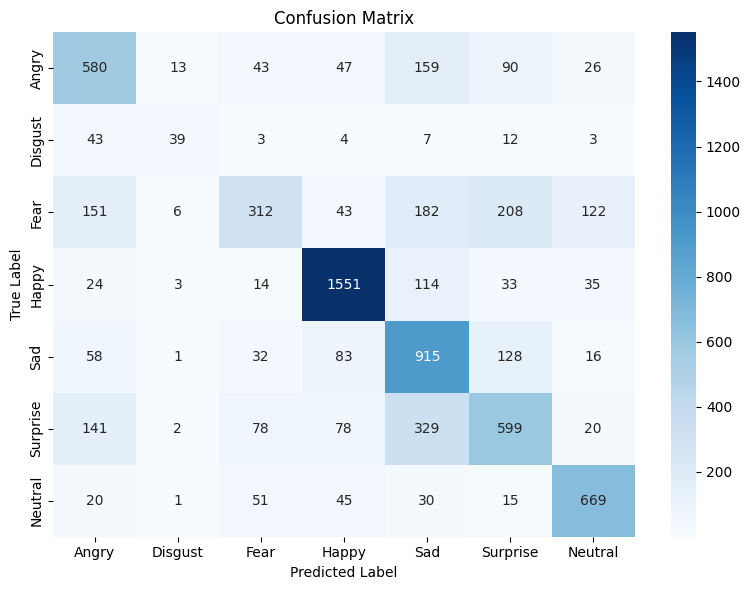

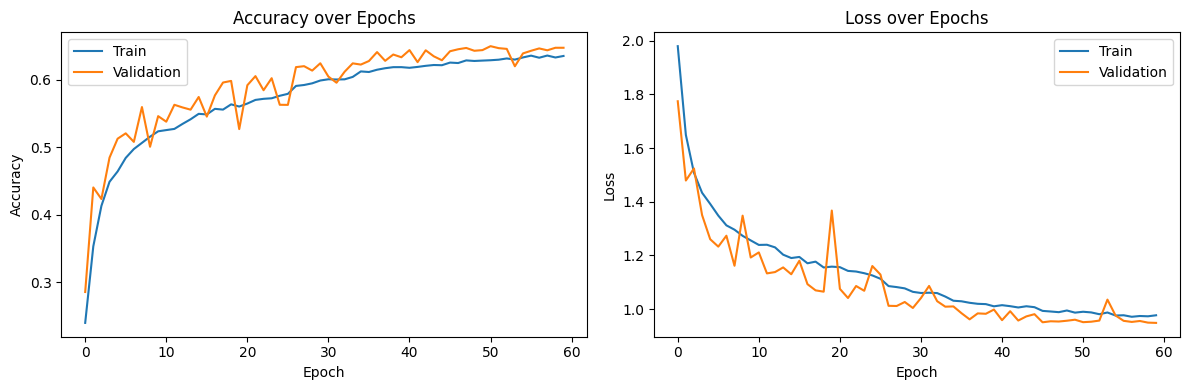


Best Val Accuracy:  64.99%
Best Val Loss:      0.9486
Epochs Run:         60
Epochs to 60%:      22


In [ ]:
import numpy as np
import psutil
import threading
import time
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# ── Reset generator so it starts from the beginning
validation_generator.reset()

# ── Collect true labels in one pass to guarantee alignment
y_true_batches = []
X_batches      = []

for i in range(len(validation_generator)):
    X_batch, y_batch = validation_generator[i]
    X_batches.append(X_batch)
    y_true_batches.append(np.argmax(y_batch, axis=1))

X_all  = np.concatenate(X_batches,      axis=0)
y_true = np.concatenate(y_true_batches, axis=0)

print(f"Collected {len(y_true)} validation samples")

# ── CPU tracking during inference
cpu_readings = []
tracking = True

def track_cpu():
    while tracking:
        cpu_readings.append(psutil.cpu_percent(interval=0.5))

tracker = threading.Thread(target=track_cpu)
tracker.start()

start_time = time.time()

# Predict on the same data we just collected (guaranteed same order)
y_pred_probs = model.predict(X_all, batch_size=64, verbose=1)

end_time = time.time()
tracking = False
tracker.join()

y_pred = np.argmax(y_pred_probs, axis=1)

# ── Performance metrics
inference_time   = end_time - start_time
avg_cpu          = sum(cpu_readings) / len(cpu_readings) if cpu_readings else 0
ram_used         = psutil.virtual_memory().used / (1024 ** 3)
tdp_watts        = 15
estimated_power  = tdp_watts * (avg_cpu / 100)
estimated_energy = estimated_power * inference_time

print("\n" + "=" * 40)
print("       PERFORMANCE METRICS")
print("=" * 40)
print(f"Inference Time:     {inference_time:.2f} seconds")
print(f"Avg CPU Usage:      {avg_cpu:.1f}%")
print(f"RAM Used:           {ram_used:.2f} GB")
print(f"Estimated Power:    {estimated_power:.2f} W")
print(f"Estimated Energy:   {estimated_energy:.2f} J")

# ── Classification report (now uses aligned y_true / y_pred)
print("\n" + "=" * 40)
print("     CLASSIFICATION REPORT")
print("=" * 40)
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ── Training history plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# ── Summary stats
best_val_acc  = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
epochs_run    = len(history.history['loss'])
epoch_to_60   = next((i+1 for i, v in enumerate(history.history['val_accuracy']) if v >= 0.60), None)

print(f"\nBest Val Accuracy:  {best_val_acc*100:.2f}%")
print(f"Best Val Loss:      {best_val_loss:.4f}")
print(f"Epochs Run:         {epochs_run}")
if epoch_to_60:
    print(f"Epochs to 60%:      {epoch_to_60}")
else:
    print("Epochs to 60%:      Not reached")

#System Info

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,294,679 (31.64 MB)

 Trainable params: 2,764,423 (10.55 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 5,528,848 (21.09 MB)

In [ ]:
import platform
import psutil

TDP_WATTS = 15

# ── Known values from previous Cells
INFERENCE_TIME  = 29.97   # seconds
AVG_CPU         = 97.5    # percent
RAM_USED_GB     = 1.55    # GB
N_IMAGES        = 7178

# ── Calculations
time_per_image_ms  = (INFERENCE_TIME / N_IMAGES) * 1000
estimated_power    = TDP_WATTS * (AVG_CPU / 100)
estimated_energy   = estimated_power * INFERENCE_TIME
energy_per_image   = (estimated_energy / N_IMAGES)

# ── Hardware info
mem  = psutil.virtual_memory()
UNIT = 1024 * 1024

print("=" * 40)
print("         HARDWARE INFO")
print("=" * 40)
print(f"Processor:         {platform.processor()}")
print(f"CPU Cores:         {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical")
print(f"Total RAM:         {mem.total / UNIT:.2f} MB")
print(f"Used RAM:          {mem.used  / UNIT:.2f} MB  ({mem.used/mem.total*100:.2f}%)")
print(f"Free RAM:          {mem.free  / UNIT:.2f} MB  ({mem.free/mem.total*100:.2f}%)")
print(f"CPU Temperature:   Not available on this system")

print("\n" + "=" * 40)
print("    INFERENCE ENERGY METRICS")
print("=" * 40)
print(f"Images Predicted:  {N_IMAGES}")
print(f"Inference Time:    {INFERENCE_TIME:.2f} seconds")
print(f"Time per Image:    {time_per_image_ms:.2f} ms")
print(f"Avg CPU Usage:     {AVG_CPU:.1f}%")
print(f"RAM Used:          {RAM_USED_GB:.2f} GB")
print(f"Estimated Power:   {estimated_power:.2f} W")
print(f"Estimated Energy:  {estimated_energy:.2f} J")
print(f"Energy per Image:  {energy_per_image:.4f} mJ")

         HARDWARE INFO
Processor:         x86_64
CPU Cores:         1 physical / 2 logical
Total RAM:         12975.54 MB
Used RAM:          921.08 MB  (7.10%)
Free RAM:          8987.02 MB  (69.26%)
CPU Temperature:   Not available on this system

    INFERENCE ENERGY METRICS
Images Predicted:  7178
Inference Time:    29.97 seconds
Time per Image:    4.18 ms
Avg CPU Usage:     97.5%
RAM Used:          1.55 GB
Estimated Power:   14.62 W
Estimated Energy:  438.31 J
Energy per Image:  0.0611 mJ
